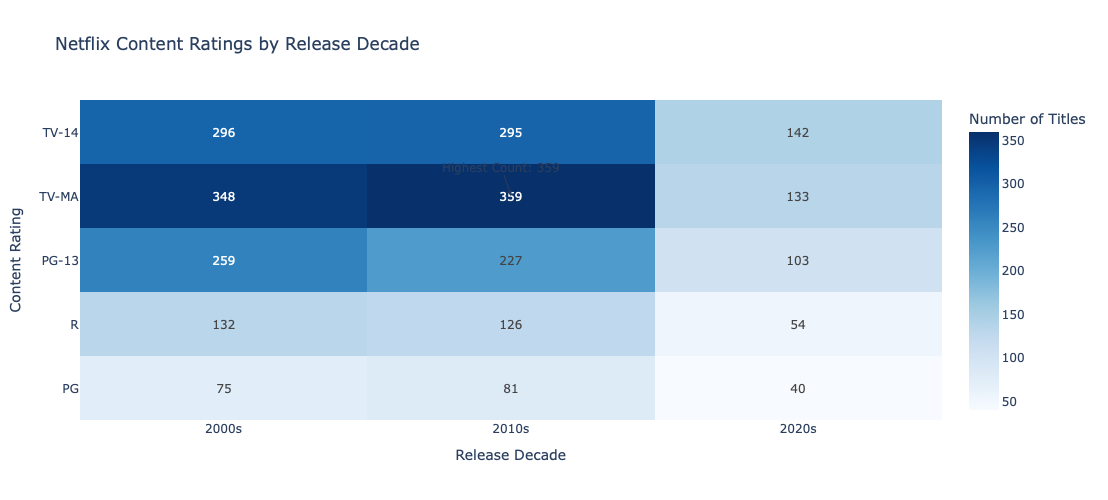

In [1]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("netflix_catalogue.csv")

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + "s"

# Keep only the most common ratings
ratings_filter = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

heatmap_df = df[df['rating'].isin(ratings_filter)]

# Create pivot table
pivot = (
    heatmap_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
    .pivot(index='rating', columns='decade', values='count')
    .fillna(0)
)

# Reorder rows
pivot = pivot.reindex(ratings_filter)

# Create heatmap
fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    labels={
        'x': 'Release Decade',
        'y': 'Content Rating',
        'color': 'Number of Titles'
    },
    title='Netflix Content Ratings by Release Decade'
)

# Add annotation for highest value
max_position = pivot.stack().idxmax()
max_value = pivot.max().max()

fig.add_annotation(
    x=max_position[1],
    y=max_position[0],
    text=f'Highest Count: {int(max_value)}',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(height=500)

fig.show()

In [ ]:
# Insights for Task 1
#TV-MA dominates the catalog, especially during the 2010s decade.
#Netflix significantly expanded mature/adult-oriented content after 2010.
#Family-friendly ratings like PG remain smaller compared to TV-MA and TV-14.
#The 2000s and 2010s contain the largest concentration of titles overall.
#Older decades have much lower content counts, indicating Netflix focuses more on modern productions.

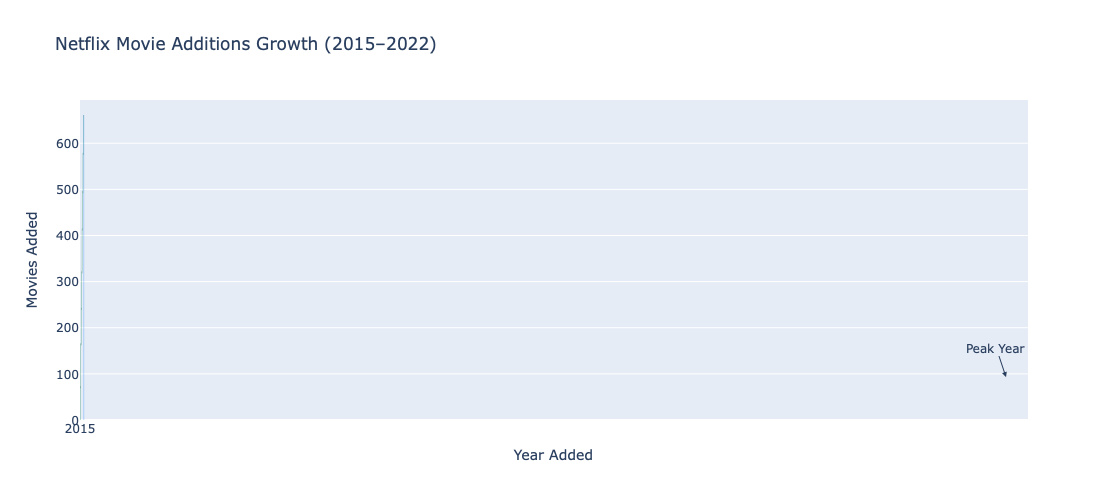

In [2]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("netflix_catalogue.csv")

# Filter movies only
movies = df[df['type'] == 'Movie'].copy()

# Count movie additions per year
movie_growth = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='count')
)

# Filter years
movie_growth = movie_growth[
    (movie_growth['added_year'] >= 2015) &
    (movie_growth['added_year'] <= 2022)
].sort_values('added_year')

# Waterfall settings
measures = ['relative'] * len(movie_growth) + ['total']

x_values = movie_growth['added_year'].astype(str).tolist() + ['Total']

y_values = movie_growth['count'].tolist() + [movie_growth['count'].sum()]

# Create waterfall chart
fig = go.Figure(go.Waterfall(
    name='Movie Additions',
    orientation='v',
    measure=measures,
    x=x_values,
    y=y_values,
    connector={"line": {"color": "gray"}}
))

# Find peak year
peak_row = movie_growth.loc[movie_growth['count'].idxmax()]

# Add annotation
fig.add_annotation(
    x=str(peak_row['added_year']),
    y=peak_row['count'],
    text='Peak Year',
    showarrow=True,
    arrowhead=2
)

# Layout
fig.update_layout(
    title='Netflix Movie Additions Growth (2015–2022)',
    xaxis_title='Year Added',
    yaxis_title='Movies Added',
    height=500
)

fig.show()

In [ ]:
#Insights for Task 2
#Netflix movie additions increased rapidly between 2015 and 2019.
#The platform experienced its peak expansion year during the late 2010s.
#Growth slowed after the peak, suggesting market saturation or strategic shifts.
#The waterfall chart clearly shows cumulative expansion in Netflix’s movie catalog.
#Netflix focused heavily on scaling movie content before stabilizing its additions later on.